## Data Preprocessing

This notebook documents the complete data preprocessing pipeline developed for our project.

### Step 1: Load Initial Dataset

First, we load the database of regular ligand-protein binding interactions, acquired from BioLiP (https://aideepmed.com/BioLiP/qsearch.cgi?lig3=regular), which was developed by the Yang Zhang lab.

In [ ]:
import os
import pandas as pd

# Define column names
columns = [
    'PDB_ID',
    'Receptor_Chain',
    'Resolution',
    'Binding_Site_Code',
    'Ligand_ID',
    'Ligand_Chain', 
    'Ligand_Serial_Number',
    'Binding_Residues_PDB',
    'Binding_Residues_Renumbered',
    'Catalytic_Residues_PDB',
    'Catalytic_Residues_Renumbered',
    'EC_Number',
    'GO_Terms',
    'Binding_Affinity_Literature',
    'Binding_Affinity_MOAD',
    'Binding_Affinity_PDBbind',
    'Binding_Affinity_BindingDB',
    'UniProt_ID',
    'PubMed_ID',
    'Ligand_Residue_Numbers',
    'Receptor_Sequence'
]

# Read the tab-separated file
database = pd.read_csv('data/BioLiP_results.txt', 
                 sep='\t', 
                 header=None, 
                 names=columns,
                 on_bad_lines="skip",
                 dtype=str)

print(database.head())
print(f"Dataframe shape: {database.shape}")
print(f"Number of Unique PDB_IDs: {len(database.PDB_ID.unique())}")

  PDB_ID Receptor_Chain Resolution Binding_Site_Code Ligand_ID Ligand_Chain  \
0   101m              A       2.07              BS01       HEM            A   
1   102m              A       1.84              BS01       HEM            A   
2   103m              A       2.07              BS01       HEM            A   
3   104m              A       1.71              BS01       HEM            A   
4   105m              A       2.02              BS01       HEM            A   

  Ligand_Serial_Number                   Binding_Residues_PDB  \
0                    1       F43 R45 V68 S92 H93 H97 I99 Y103   
1                    1   F43 R45 T67 L89 S92 H93 H97 I99 Y103   
2                    1           F43 R45 S92 H93 H97 I99 Y103   
3                    1  F43 R45 V68 S92 H93 H97 I99 Y103 F138   
4                    1        F43 R45 H64 V68 L89 H93 H97 I99   

             Binding_Residues_Renumbered Catalytic_Residues_PDB  ...  \
0      F44 R46 V69 S93 H94 H98 I100 Y104                    Na

This file contains 496960 interactions-entries along 112911 unique PDB codes.

### Step 2: Initial FIltering

Our initial filtering aims to ensure high structural quality and biological relevance. 
In this step, we restrict the data to peer-reviewed structures (PubMed verified) with a resolution $\le$ 2.5 Å and mapped UniProt entries, while excluding common crystallographic artifacts, solvents, simple ions and carbohydrates that do not represent functional drug-like binding pockets. Also, we exclude non-specific surface interactions (<5 res), ensuring a higher degree of enclosure.

In [ ]:
# PubMed filter
pdb_filtered = database[~database["PubMed_ID"].isna()].copy()

# Resolution filters
pdb_filtered['Resolution'] = pd.to_numeric(pdb_filtered['Resolution'], errors='coerce')
pdb_filtered = pdb_filtered[pdb_filtered['Resolution'] > 0].copy() # NMR structures
pdb_filtered = pdb_filtered[pdb_filtered['Resolution'] <= 2.5].copy()

# Ligand exclusion
# ===== Ligand exclusion list =====
exclude_ligands = {
    # Standard Amino Acids & Peptide Fragments
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL",
    "SEC", "PYL", "GSH", "ACE", "NH2", "NFA",
    # Nucleotide Fragments
    "DA", "DG", "DC", "DT", "DI", "A", "G", "C", "U", "I",
    # Small Inorganic Ions & Clusters
    "HOH", "WAT", "DOD", "CL", "NA", "K", "CA", "MG", "MN", "FE", "CU", "CD", "CO",
    "SO4", "PO4", "NO3", "CO3", "BO4", "SCN", "IOD", "BR", "F", "IO3", "AZI", "OXY",
    "OXL", "WO4", "SF4", "F3S", "F43", "CUA", "CUZ",
    # Sugars and Carbohydrates
    "NAG", "MAN", "BMA", "FUC", "FUL", "NDG", "GLC", "BGC", "GAL", "GLA", "SIA", "XYP",
    "GOL", "SUC", "TRE", "FRU", "MAL", "RIB",
    # Crystallization Buffers, Solvents, Artifacts
    "ACT", "DMS", "EDO", "PEG", "TRS", "CIT", "FLC", "BCT", "DTT", "TLA", "D10", "P6G",
    "MPD", "BME", "MES", "HEP", "EPE", "IMD", "ACY", "FMT",
    "PGE", "PG4", "PE4", "1PE", "EOH", "MOH", "IPA", "SO3",
    # Heavy Metals and Other Elements
    "SE", "KR", "NI", "AS", "YB", "RU", "HG", "HG2", "LI", "BA", "SR", "RA", "AL",
    "PB", "BI", "SN", "SB", "CS", "MO", "W",
    # Unspecified/Ambiguous
    "UNK", "UNX"
}

pdb_filtered = pdb_filtered[~pdb_filtered['Ligand_ID'].isin(exclude_ligands)].copy()

# Minimum binding site size 5 residues
pdb_filtered = pdb_filtered[pdb_filtered['Binding_Residues_PDB'].apply(
    lambda x: len(x.split()) if pd.notna(x) else 0) >= 5].copy()

# Drop no UniProt (engineered & obsolete structures)
pdb_filtered = pdb_filtered[~pdb_filtered['UniProt_ID'].isna()].copy()

# Save filtered dataset
if not os.path.exists("data"):
    os.makedirs("data/")
pdb_filtered.to_csv("data/filtered_pdbs.csv")

print(f"Shape: {pdb_filtered.shape}")
print(f"Unique PDB_IDs: {pdb_filtered['PDB_ID'].nunique()}")
print(f"Unique UniProt_IDs: {pdb_filtered['UniProt_ID'].nunique()}")

Shape: (137675, 21)
Unique PDB_IDs: 54903
Unique UniProt_IDs: 12022


After this, we end up with 54903 structures across UniProt IDs

### Step 3: Exclude Unavailable PDBS

Next, we check via the RCSB Protein Data Bank (PDB) GraphQL API for structures lacking .pdb file and exclude them.

In [ ]:
import requests
import pandas as pd
import logging
import time

# Track the API synchronization progress and errors
logging.basicConfig(
    filename="pdb_check.log",
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)


def query_chunk(url: str, ids_str: str, retries: int = 3, wait: int = 5) -> None:
    """
    Sends a GraphQL query to the RCSB PDB API for a specific chunk of PDB IDs.
    
    Args:
        url (str): RCSB GraphQL endpoint.
        ids_str (str): JSON list of PDB IDs (e.g., '["1A9W", "1ZED"]').
        retries (int): Number of times to attempt the request if failure. Defaults to 3.
        wait (int): Wait time (sec). Defaults to 5.
        
    Returns:
        dict: The JSON response from the API, or None if all retries fail.
    """

    # GraphQL query: Requesting the ID and the PDB-format compatibility status
    query = f"""
    {{
      entries(entry_ids: {ids_str}) {{
        rcsb_id
        pdbx_database_status {{
          pdb_format_compatible
        }}
      }}
    }}
    """

    for attempt in range(retries):
        try:
            response = requests.post(url, json={"query": query}, timeout=30)
            response.raise_for_status() # Raise error for bad status
            return response.json()
        except Exception as e:
            logging.warning(f"Attempt {attempt+1}/{retries} failed: {e}")
            if attempt < retries - 1:
                time.sleep(wait) # backoff/wait

    logging.error(f"All {retries} attempts failed for chunk: {ids_str[:80]}...")
    return None


def get_pdb_compatible_ids(pdb_ids: list, chunk_size: int = 1000) -> set:
    """
    Iterates through a list of PDB IDs in batches to verify their existence 
    and PDB file format compatibility.
    
    Args:
        pdb_ids (list): List of PDB IDs.
        chunk_size (int): Number of IDs to process per call.
        
    Returns:
        set: Valid, PDB-compatible IDs (lowercase).
    """

    url = "https://data.rcsb.org/graphql"
    valid_ids = set()
    pdb_ids = list(pdb_ids)
    total = len(pdb_ids)

    print(f"Checking {total} PDB IDs in batches of {chunk_size}...")
    logging.info(f"Starting check for {total} PDB IDs in batches of {chunk_size}")

    for i in range(0, total, chunk_size):
        chunk = pdb_ids[i:i + chunk_size]
        ids_str = '["' + '","'.join(c.upper() for c in chunk) + '"]'

        data = query_chunk(url, ids_str)

        if data is None:
            logging.error(f"Skipping chunk {i}–{i+chunk_size} after all retries failed")
            logging.info(f"Processed {min(i + chunk_size, total)}/{total}")
            continue

        # Parse JSON response
        for entry in data.get("data", {}).get("entries", []):
            if (entry
                    and entry.get("pdbx_database_status")
                    and entry["pdbx_database_status"]["pdb_format_compatible"] == "Y"):
                valid_ids.add(entry["rcsb_id"].lower())

        logging.info(f"Processed {min(i + chunk_size, total)}/{total}")

    return valid_ids


# Read filtered data
pdb_filtered = pd.read_csv("data/filtered_pdbs.csv")

# Get unique IDs
unique_pdb_ids = pdb_filtered["PDB_ID"].unique()
print(f"Total unique PDB IDs in dataset: {len(unique_pdb_ids)}")

# Get valid IDs
valid_ids = get_pdb_compatible_ids(unique_pdb_ids)

unavailable = set(p.lower() for p in unique_pdb_ids) - valid_ids
print(f"\nResults:")
print(f"Available PDBs:   {len(valid_ids)}")
print(f"Unavailable PDBs: {len(unavailable)}")

# Filter valid IDs
pdb_filtered = pdb_filtered[
    pdb_filtered["PDB_ID"].str.lower().isin(valid_ids)
].copy()

print(f"\nFiltered dataset:")
print(f"Unique UniProt IDs: {pdb_filtered['UniProt_ID'].nunique()}")
print(f"Unique PDB IDs: {pdb_filtered['PDB_ID'].nunique()}")

pdb_filtered.to_csv("data/filtered_pdbs.csv", index=False)

/tmp/ipykernel_25979/2669742392.py:68: DtypeWarning: Columns (14,20) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_filtered = pd.read_csv("data/filtered_pdbs.csv")


Total unique PDB IDs in dataset: 54903
Checking 54903 PDB IDs in batches of 1000...

Results:
Available PDBs:   53496
Unavailable PDBs: 1407

Filtered dataset:
Unique UniProt IDs: 11806
Unique PDB IDs: 53496


After this step, we get 53496 structures.

### Step 4: Orthosteric Conserved Site Selection

Following, we implement a functional analysis per UniProt ID to detect the protein's primary binding regions. Conserved residues are clustered to find multi-site architectures and the PDB with the maximum site coverage and higherst resolution is selected. This ensures the final dataset is non-redundant while prioritizing the most biologically complete structural representatives. 

In [2]:
import pandas as pd

def get_orthosteric_pdb(group: pd.DataFrame) -> pd.DataFrame:
    from collections import Counter
    
    group = group.copy()
    #total_rows = len(group)
    
    # Count residue frequency across all rows
    residue_counts = Counter()
    for res_str in group['Binding_Residues_PDB'].dropna():
        residue_counts.update(res_str.split())
    
    total_ligands = group['Ligand_ID'].nunique()
    
    # Identify conserved residues (appear in >30% of ligand instances)
    conserved_residues = {
        res for res, count in residue_counts.items()
        if count / total_ligands >= 0.3
    }
    
    if not conserved_residues:
        # No conserved residues at all → just pick best resolution
        best_idx = group['Resolution'].idxmin()
        return group.loc[[best_idx]]
    
    # Detect if multiple orthosteric sites exist
    # Cluster orthosteric residues by co-occurrence in same pocket
    def get_pocket_sets(group, conserved_residues):
        """Get sets of orthosteric residues for each specific ligand"""
        pocket_sets = []
        for res_str in group['Binding_Residues_PDB'].dropna():
            pocket = set(res_str.split()) & conserved_residues
            if pocket:
                pocket_sets.append(frozenset(pocket))
        return pocket_sets
    
    pocket_sets = get_pocket_sets(group, conserved_residues)
    
    # Check if orthosteric residues cluster into non-overlapping groups
    # by checking if any two pockets have zero overlap
    has_multiple_sites = False
    site_clusters = []

    for pocket in pocket_sets:
        placed = False
        for cluster in site_clusters:
            # If pocket overlaps with cluster → same functional site
            if len(pocket & cluster) > 0:
                cluster.update(pocket)
                placed = True
                break
        if not placed:
            site_clusters.append(set(pocket))
    
    # Merge overlapping clusters
    merged = True
    while merged:
        merged = False
        new_clusters = []
        used = set()
        for i, c1 in enumerate(site_clusters):
            if i in used:
                continue
            for j, c2 in enumerate(site_clusters):
                if j <= i or j in used:
                    continue
                if len(c1 & c2) > 0:
                    c1 = c1 | c2
                    used.add(j)
                    merged = True
            new_clusters.append(c1)
            used.add(i)
        site_clusters = new_clusters
    
    has_multiple_sites = len(site_clusters) > 1
    
    # Single orthosteric site → keep best resolution PDB with highest overlap
    if not has_multiple_sites:
        def orthosteric_overlap(res_str):
            if pd.isna(res_str): return 0
            pocket = set(res_str.split())
            return len(pocket & conserved_residues) / len(conserved_residues)
        
        # Prioritize PDBs that capture at least 50% of the consensus residues
        group['Orthosteric_Overlap'] = group['Binding_Residues_PDB'].apply(orthosteric_overlap)
        high_overlap = group[group['Orthosteric_Overlap'] >= 0.5]
        if len(high_overlap) == 0:
            high_overlap = group
        
        best_idx = high_overlap['Resolution'].idxmin()
        return group.loc[[best_idx]]
    
    else:
        # Multiple distrinct sites → find PDB covering most sites at best resolution
        # Score each PDB by how many sites it covers
        def count_sites_covered(pdb_group, site_clusters):
            """Counts how many of the identified site clusters are represented in a PDB."""
            all_residues = set()
            for res_str in pdb_group['Binding_Residues_PDB'].dropna():
                all_residues.update(res_str.split())
            
            sites_covered = 0
            for cluster in site_clusters:
                overlap = len(all_residues & cluster) / len(cluster)
                if overlap >= 0.3:  # covers at least 30% of that site
                    sites_covered += 1
            return sites_covered
        
        ## Score every PDB ID by coverage and resolution
        pdb_scores = []
        for pdb_id, pdb_group in group.groupby('PDB_ID'):
            sites_covered = count_sites_covered(pdb_group, site_clusters)
            resolution = pdb_group['Resolution'].iloc[0]
            pdb_scores.append({
                'PDB_ID': pdb_id,
                'Sites_Covered': sites_covered,
                'Resolution': resolution
            })
        
        pdb_scores_df = pd.DataFrame(pdb_scores)
        
        # Prefer PDB covering most sites, then best resolution
        pdb_scores_df = pdb_scores_df.sort_values(
            ['Sites_Covered', 'Resolution'], 
            ascending=[False, True]
        )
        
        best_pdb_id = pdb_scores_df.iloc[0]['PDB_ID']
        best_row = group[group['PDB_ID'] == best_pdb_id].iloc[[0]]
        return best_row

# Read filtered data
pdb_filtered = pd.read_csv("data/filtered_pdbs.csv")

# Remove chimeric/fusion proteins
composite_mask = pdb_filtered['UniProt_ID'].str.contains(',', na=False)
pdb_filtered = pdb_filtered[~composite_mask].copy().reset_index(drop=True)

# Apply selection per UniProt
best_per_uniprot = pdb_filtered.groupby('UniProt_ID', group_keys=False).apply(get_orthosteric_pdb)

# Reflect back to the main dataset to include all chains/ligands
best_pdb_ids = best_per_uniprot['PDB_ID'].unique()
pdb_filtered_final = pdb_filtered[pdb_filtered['PDB_ID'].isin(best_pdb_ids)].copy().reset_index(drop=True)

print(f"Reduced from {len(pdb_filtered):,} → {len(pdb_filtered_final):,} rows")
print(f"Unique PDB_IDs: {pdb_filtered_final['PDB_ID'].nunique()}")
print(f"Unique UniProt_IDs: {pdb_filtered_final['UniProt_ID'].nunique()}")

/tmp/ipykernel_73837/335012173.py:134: DtypeWarning: Columns (14,20) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_filtered = pd.read_csv("data/filtered_pdbs.csv")


Reduced from 130,107 → 33,598 rows
Unique PDB_IDs: 11249
Unique UniProt_IDs: 11657


/tmp/ipykernel_73837/335012173.py:141: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_per_uniprot = pdb_filtered.groupby('UniProt_ID', group_keys=False).apply(get_orthosteric_pdb)


Therefore, we get 11249 structures across 11657 Uniprots

##### Check distribution of PDBs - UniProt IDs

In [ ]:
pdb_uniprot_count = pdb_filtered_final.groupby('PDB_ID')['UniProt_ID'].nunique()
multi_uniprot_pdbs = pdb_uniprot_count[pdb_uniprot_count > 1]

# Get multi-Uniprot pdbs
multi_uniprot_df = (
    pdb_filtered_final[pdb_filtered_final['PDB_ID'].isin(multi_uniprot_pdbs)]
    .groupby('PDB_ID')
    .agg(
        UniProt_Count=('UniProt_ID', 'nunique'),
        UniProt_IDs=('UniProt_ID', lambda x: ', '.join(sorted(x.unique()))),
        Chains=('Receptor_Chain', lambda x: ', '.join(sorted(x.unique()))),
        Resolution=('Resolution', 'first')
    )
    .reset_index()
    .sort_values('UniProt_Count', ascending=False)
)

# Save multi-Uniprot pdbs
multi_uniprot_df.to_csv('data/multi_uniprot_pdbs.csv', index=False)

print(f"PDBs mapped to more than one UniProt: {len(multi_uniprot_pdbs)}")
print(f"\nDistribution of UniProt counts per PDB:")
print(pdb_uniprot_count.value_counts().sort_index())

PDBs mapped to more than one UniProt: 354

Distribution of UniProt counts per PDB:
UniProt_ID
1     10895
2       252
3        50
4        15
5        10
6         3
7         5
8         9
9         5
10        4
21        1
Name: count, dtype: int64


#### Step 5: Remove complexes with more that 2 UniProt IDs and remap

To limit structural complexity and ensure computational efficiency we remove PDBs containing more than two unique UniProt IDs and check affected proteins for alternative (Monomers/Dimers) available.

In [ ]:
# Identify PDBs with more than 2 UniProt IDs
pdb_uniprot_count = pdb_filtered_final.groupby('PDB_ID')['UniProt_ID'].nunique()
complex_pdbs = pdb_uniprot_count[pdb_uniprot_count > 2].index

# Remove large complexes from pool and re-run selection
df_filtered = pdb_filtered[~pdb_filtered['PDB_ID'].isin(complex_pdbs)].copy()

best_per_uniprot = df_filtered.groupby('UniProt_ID', group_keys=False).apply(get_orthosteric_pdb)
winner_pdb_ids = best_per_uniprot['PDB_ID'].unique()
df_final = df_filtered[df_filtered['PDB_ID'].isin(winner_pdb_ids)].copy().reset_index(drop=True)

In [27]:
pdb_uniprot_count = df_final.groupby('PDB_ID')['UniProt_ID'].nunique()
multi_uniprot_pdbs = pdb_uniprot_count[pdb_uniprot_count > 1]

print(f"PDBs mapped to more than one UniProt: {len(multi_uniprot_pdbs)}")
print(f"\nDistribution of UniProt counts per PDB:")
print(pdb_uniprot_count.value_counts().sort_index())

PDBs mapped to more than one UniProt: 257

Distribution of UniProt counts per PDB:
UniProt_ID
1    10901
2      257
Name: count, dtype: int64


The final pool of PDB strcutures include 10901 Homomers and 257 PDBs with 2 UniProt IDs mapped

In [8]:
df_final

,Unnamed: 0,PDB_ID,Receptor_Chain,Resolution,Binding_Site_Code,Ligand_ID,Ligand_Chain,Ligand_Serial_Number,Binding_Residues_PDB,Binding_Residues_Renumbered,...,EC_Number,GO_Terms,Binding_Affinity_Literature,Binding_Affinity_MOAD,Binding_Affinity_PDBbind,Binding_Affinity_BindingDB,UniProt_ID,PubMed_ID,Ligand_Residue_Numbers,Receptor_Sequence
0,34,12as,A,2.20,BS02,AMP,A,1,R100 L109 S111 V114 Q116 L249 S250 G296 R299,R97 L106 S108 V111 Q113 L246 S247 G293 R296,...,6.3.1.1,"0004071,0005524,0005737,0005829,0006529,000697...",NaN,NaN,NaN,NaN,P00963,9437423,332,AYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLS...
1,36,12as,B,2.20,BS02,AMP,B,1,R100 E103 S111 V114 Q116 E248 L249 S250 S251 G...,R97 E100 S108 V111 Q113 E245 L246 S247 S248 G2...,...,6.3.1.1,"0004071,0005524,0005737,0005829,0006529,000697...",NaN,NaN,NaN,NaN,P00963,9437423,332,AYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLS...
2,49,16pk,A,1.60,BS01,BIS,A,1,G217 A218 K223 A242 Y245 L315 P340 G342 V343 E...,G213 A214 K219 A238 Y241 L311 P336 G338 V339 E...,...,2.7.2.3,"0004618,0005524,0005829,0006094,0006096,001630...",NaN,NaN,NaN,NaN,P07378,9642090,499,EKKSINECDLKGKKVLIRVDFNVPVKNGKITNDYRIRSALPTLKKV...
3,92,1a05,A,2.00,BS01,IPM,A,1,R95 R105 R133 Y140 D246,R95 R105 R133 Y140 D246,...,1.1.1.85,"0000287,0003862,0005737,0005829,0009098,001649...",NaN,NaN,NaN,NaN,Q56268,9739088,401,MKKIAIFAGDGIGPEIVAAARQVLDAVDQAAHLGLRCTEGLVGGAA...
4,93,1a05,B,2.00,BS01,IPM,B,1,R95 R105 R133 Y140 D246,R95 R105 R133 Y140 D246,...,1.1.1.85,"0000287,0003862,0005737,0005829,0009098,001649...",NaN,NaN,NaN,NaN,Q56268,9739088,402,MKKIAIFAGDGIGPEIVAAARQVLDAVDQAAHLGLRCTEGLVGGAA...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30705,492494,9krr,J,1.93,BS01,HEC,J,1,N13 C14 C17 H18 N23 K29 T30 L31 D35 N39 Q50 I5...,N14 C15 C18 H19 N24 K30 T31 L32 D36 N40 Q51 I5...,...,NaN,NaN,NaN,NaN,NaN,NaN,P46445,39859539,101,SADLAHGKAIFAGNCAACHNGGLNAINPSKTLKMADLEANGKNSVA...
30706,492495,9krr,K,1.93,BS01,HEC,K,1,N13 C14 C17 H18 N23 I25 K29 T30 L31 D35 L36 N3...,N15 C16 C19 H20 N25 I27 K31 T32 L33 D37 L38 N4...,...,NaN,NaN,NaN,NaN,NaN,NaN,P46445,39859539,101,GSADLAHGKAIFAGNCAACHNGGLNAINPSKTLKMADLEANGKNSV...
30707,492496,9krr,L,1.93,BS01,HEC,L,1,N13 C14 C17 H18 N23 K29 T30 L31 D35 L36 N39 Q5...,N15 C16 C19 H20 N25 K31 T32 L33 D37 L38 N41 Q5...,...,NaN,NaN,NaN,NaN,NaN,NaN,P46445,39859539,101,GSADLAHGKAIFAGNCAACHNGGLNAINPSKTLKMADLEANGKNSV...
30708,492867,9ldt,A,2.00,BS01,NAD,A,1,G30 A31 V32 D53 V54 T97 A98 G99 A100 R101 F122...,G28 A29 V30 D51 V52 T94 A95 G96 A97 R98 F118 V...,...,1.1.1.27,"0003824,0004459,0005737,0016491,0016616,0019752",NaN,NaN,NaN,NaN,P00339,1678537,401,ATLKDQLIHNLLKEEHVPHNKITVVGVGAVGMACAISILMKELADE...


Save results

In [9]:
result = (
    df_final[[
        'PDB_ID', 
        'UniProt_ID', 
        'Receptor_Chain', 
        'Binding_Site_Code', 
        'Ligand_ID', 
        'Ligand_Chain', 
        'Ligand_Serial_Number', 
        'Binding_Residues_PDB'
    ]]
    .drop_duplicates()
    .sort_values(['UniProt_ID', 'PDB_ID', 'Receptor_Chain'])
    .reset_index(drop=True)
)

result.to_csv('data/uniprot_pdb_mapping.csv', index=False)

print(f"Shape: {result.shape}")
print(f"Unique UniProt_IDs: {result['UniProt_ID'].nunique()}")
print(f"Unique PDB_IDs: {result['PDB_ID'].nunique()}")
print(result.head(10))

Shape: (30710, 8)
Unique UniProt_IDs: 11313
Unique PDB_IDs: 11158
  PDB_ID  UniProt_ID Receptor_Chain Binding_Site_Code Ligand_ID Ligand_Chain  \
0   6kv9      A0A003              A              BS01       NAD            A   
1   6kv9      A0A003              A              BS02       UGA            A   
2   3vk5      A0A011              A              BS01       FPQ            A   
3   3vk5      A0A011              B              BS02       FPQ            B   
4   6gmf  A0A017T5A5              A              BS01       HEM            A   
5   6sj3  A0A022MQ12              A              BS01       3HB            A   
6   6sj3  A0A022MQ12              B              BS01       3HB            B   
7   6siy  A0A022MRT4              A              BS01       3HA            A   
8   6siy  A0A022MRT4              A              BS02       AMP            A   
9   6siy  A0A022MRT4              A              BS03       3HA            A   

   Ligand_Serial_Number                              

##### Step 6: Structural Reduction and Chain Selection

Due to data inconsistencies, we continue with the homomeric structures. For computational efficiency, we keep a single representative chain of each structure. We calculate the union of all binding residues across all ligands and sites per chain, and select the representative chain based on the highest interaction density.

In [ ]:
import pandas as pd

df = pd.read_csv("data/uniprot_pdb_mapping.csv")
df['Ligand_Serial_Number'] = df['Ligand_Serial_Number'].astype(str)

# Only process PDBs with exactly one UniProt ID
pdb_uniprot_count = df.groupby('PDB_ID')['UniProt_ID'].nunique()
single_uniprot_pdbs = pdb_uniprot_count[pdb_uniprot_count == 1].index
df_homo = df[df['PDB_ID'].isin(single_uniprot_pdbs)].copy()

print(f"PDBs to process (single UniProt): {df_homo['PDB_ID'].nunique()}")
print(f"PDBs skipped (multiple UniProt):  {(pdb_uniprot_count > 1).sum()}")

records = []

for pdb_id, pdb_group in df_homo.groupby('PDB_ID'):

    chains = pdb_group['Receptor_Chain'].unique()

    if len(chains) == 1:
        # Single chain: union all binding residues across all ligands/sites
        chain = chains[0] # Only one chain 
        residues = set()
        for res_str in pdb_group['Binding_Residues_PDB'].dropna():
            for res in res_str.split():
                residues.add(f"{chain}_{res}") 
        records.append({
            'PDB_ID': pdb_id,
            'Chains_To_Keep': chain,
            'Binding_Residues': ' '.join(sorted(residues))
        })

    else:
        # Multiple chains: collect union of all binding residues per chain
        chain_residues = {}
        for chain, chain_group in pdb_group.groupby('Receptor_Chain'):
            residues = set()
            for res_str in chain_group['Binding_Residues_PDB'].dropna():
                for res in res_str.split():
                    residues.add(res)
            chain_residues[chain] = residues

        # Keep chain with most binding residues (union across all ligands/sites)
        best_chain = max(chain_residues, key=lambda c: len(chain_residues[c]))
        best_residues = chain_residues[best_chain]

        records.append({
            'PDB_ID': pdb_id,
            'Chains_To_Keep': best_chain,
            'Binding_Residues': ' '.join(sorted(f"{res}" for res in best_residues))
        })

result = pd.DataFrame(records)
result.to_csv('data/pdb_processing_info.csv', index=False)

print(f"\nOutput shape: {result.shape}")
print(f"Unique PDBs: {result['PDB_ID'].nunique()}")
print(result.head(5))

PDBs to process (single UniProt): 10901
PDBs skipped (multiple UniProt):  257

Output shape: (10901, 3)
Unique PDBs: 10901
  PDB_ID Chains_To_Keep                                   Binding_Residues
0   12as              B  E103 E248 G296 L249 Q116 R100 R299 S111 S250 S...
1   16pk              A  A218 A242 E345 G217 G342 G397 G398 G399 K223 L...
2   1a05              A                            D246 R105 R133 R95 Y140
3   1a49              G  A4565 G4562 H4277 K4406 N4274 P4252 R4272 R431...
4   1a4e              A  F148 F156 F331 H359 H70 N143 N68 P69 R107 R351...


Get UniProt IDs for Protein Classification

In [7]:
import pandas as pd

pdb_processing_info = pd.read_csv('data/pdb_processing_info.csv')
uniprot_mapping = pd.read_csv('data/uniprot_pdb_mapping.csv')

# Get unique UniProt per PDB from mapping
pdb_to_uniprot = (
    uniprot_mapping[uniprot_mapping['PDB_ID'].isin(pdb_processing_info['PDB_ID'])]
    [['PDB_ID', 'UniProt_ID']]
    .drop_duplicates()
    .sort_values(['PDB_ID', 'UniProt_ID'])
    .reset_index(drop=True)
)

pdb_to_uniprot.to_csv('data/pdb_uniprot_ids.csv', index=False)

print(f"Shape: {pdb_to_uniprot.shape}")
print(pdb_to_uniprot.head(10))

Shape: (10901, 2)
  PDB_ID UniProt_ID
0   12as     P00963
1   16pk     P07378
2   1a05     Q56268
3   1a49     P11974
4   1a4e     P15202
5   1a4m     P03958
6   1a54     P0AG82
7   1a59     O34002
8   1a5z     P16115
9   1a65     Q9Y780


#### Step 7: Functional Annotation and Classification

Following the structural selection, we fetch Molecular Function annotation from UniProt for every protein in our dataset. These annotations are used to classifing proteins into functional groups and ensure a stratified distribution during the data splitting process.

In [ ]:
import pandas as pd
import requests
import time

df = pd.read_csv("data/pdb_uniprot_ids.csv")

def fetch_mol(uniprot_ids: list[str], batch_size: int = 50, sleep: float = 0.3) -> dict[str, str]:
    """
    Query the UniProt REST API to retrieve Molecular Function for a list of proteins.

    Args:
        uniprot_ids: List of UniProt IDs.
        batch_size: Number of IDs per API request.
        sleep: Wait time (sec).

    Returns:
        Mapping UniProt Accessions to primary Molecular Function keyword.
    """

    results = {}
    total   = (len(uniprot_ids) + batch_size - 1) // batch_size

    for i in range(0, len(uniprot_ids), batch_size):
        batch  = uniprot_ids[i : i + batch_size]
        query  = " OR ".join(f"accession:{uid}" for uid in batch)
        params = {
            "query":  query,
            "fields": "accession,keyword",
            "format": "json",
            "size":   batch_size,
        }
        try:
            resp = requests.get("https://rest.uniprot.org/uniprotkb/search",
                                params=params, timeout=30)
            resp.raise_for_status()
            for entry in resp.json().get("results", []):
                acc    = entry["primaryAccession"]
                mol_fn = [
                    kw["name"] for kw in entry.get("keywords", [])
                    if kw.get("category") == "Molecular function"
                ]
                results[acc] = mol_fn[0] if mol_fn else "UNKNOWN"
        except Exception as e:
            print(f"[ERROR] {e}")
            for uid in batch:
                results[uid] = "UNKNOWN"

        time.sleep(sleep)
        #print(f"Batch {i//batch_size+1}/{total} done", end="\r")

    return results

# Fetch and add column
unique_ids = df["UniProt_ID"].dropna().unique().tolist()
mol_map = fetch_mol(unique_ids)

df["Protein_Class_Uniprot"] = df["UniProt_ID"].map(mol_map)
df.to_csv("data/pdb_uniprot_class.csv", index=False)

# Summary
print(df["Protein_Class_Uniprot"].value_counts())
print(f"\nCoverage: {(df['Protein_Class_Uniprot'] != 'UNKNOWN').sum():,} / {len(df):,}")

Protein_Class_Uniprot
UNKNOWN                    2102
Oxidoreductase             1521
Hydrolase                  1287
Kinase                      606
Transferase                 525
                           ... 
Prion                         1
IgG-binding protein           1
Taste-modifying protein       1
Superantigen                  1
Viral nucleoprotein           1
Name: count, Length: 100, dtype: int64

Coverage: 8,799 / 10,901


Out of the total dataset, 8,799 proteins were successfully mapped to a verified UniProt Molecular Function. The remaining 2,102 entries labeled as 'UNKNOWN' have been excluded but remain a valuable resource for feature developments.

Visualize distribution of classes

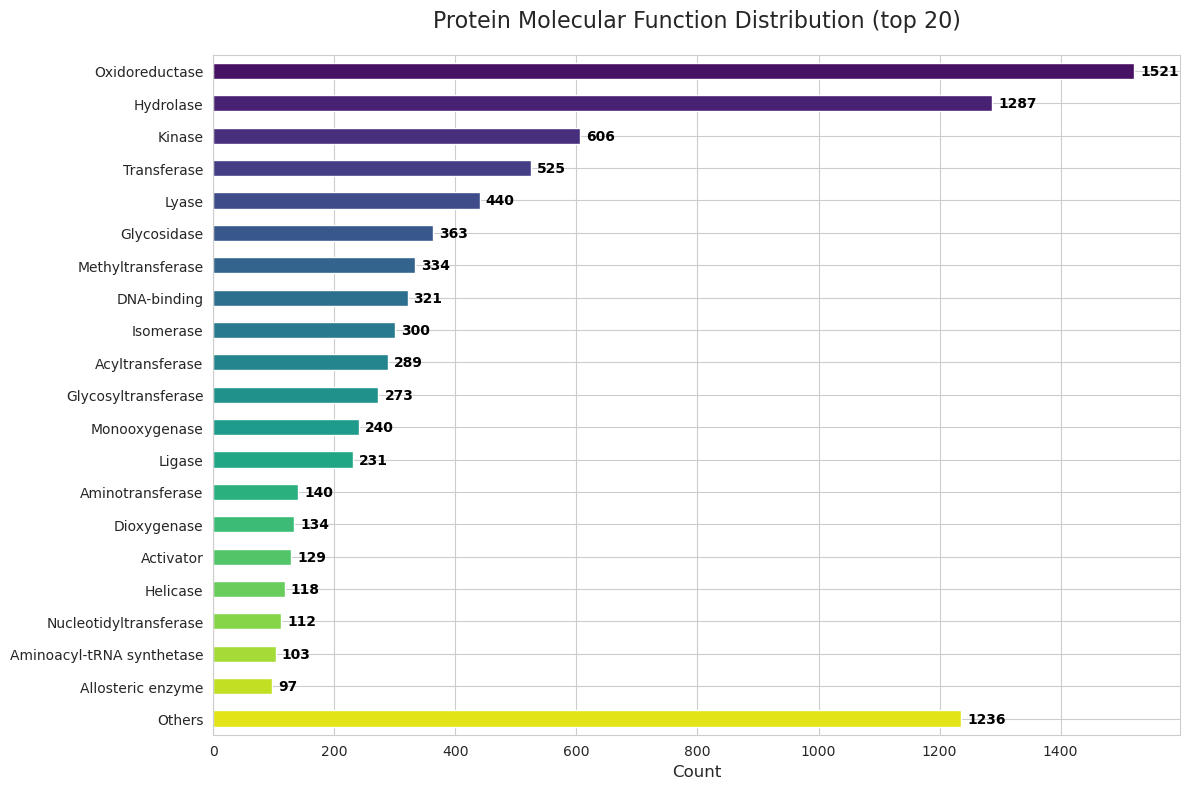

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/pdb_uniprot_class.csv")

# remove 'UNKNOWN' for the visualization
plot_df = df[df["Protein_Class_Uniprot"] != "UNKNOWN"].copy()

# Get the counts
counts = plot_df["Protein_Class_Uniprot"].value_counts()

# Show top 15 classes, group rest as 'Others'
top_n = 20
top_classes = counts.iloc[:top_n]
others_count = counts.iloc[top_n:].sum()

# Create plotting dataset
final_counts = pd.concat([top_classes, pd.Series({"Others": others_count})])

# Plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Horizontal bar chart
colors = sns.color_palette("viridis", len(final_counts))
ax = final_counts.plot(kind='barh', color=colors)

plt.title(fr"Protein Molecular Function Distribution (top {top_n})", fontsize=16, pad=20)
plt.xlabel("Count", fontsize=12)
plt.gca().invert_yaxis()  # Put the largest class at the top

# Add count labels to the end of each bar
for i, v in enumerate(final_counts):
    ax.text(v + 10, i, str(int(v)), color='black', va='center', fontweight='bold')

plt.tight_layout()
#plt.savefig("data/protein_class_distribution.png", dpi=300)
plt.show()

#### Step 8: Split dataset for Stratified Cross-Validation

We partitioned our 8,799 annotated proteins into an 80% training set and a 20% independent testing set. We use Stratified Selection to ensure that each split maintains the original distribution of protein functional classes. Furthermore, the training set is divided into 5 stratified cross-validation folds. Rare protein classes (<5 members) are grouped into a 'RARE' category to ensure statistical stability during the split.

In [8]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold

# Load files
info = pd.read_csv('data/pdb_processing_info.csv')
clss  = pd.read_csv('data/pdb_uniprot_class.csv')

# Merge class info onto processing info
df = info.merge(clss[['PDB_ID', 'Protein_Class_Uniprot']], on='PDB_ID', how='left')

# Separate UNKNOWN from the rest
known_df   = df[df['Protein_Class_Uniprot'] != 'UNKNOWN'].copy()
unknown_df = df[df['Protein_Class_Uniprot'] == 'UNKNOWN'].copy()

# Group rare classes (< 5 members) into RARE to allow stratified split
class_counts = known_df['Protein_Class_Uniprot'].value_counts()
known_df['stratify_label'] = known_df['Protein_Class_Uniprot'].apply(
    lambda x: x if class_counts.get(x, 0) >= 5 else 'RARE'
)

# Train / Test split (80/20) on known only
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(known_df, known_df['stratify_label']))

known_df['Split'] = 'testing'
known_df.loc[known_df.iloc[train_idx].index, 'Split'] = 'training'

# CV Batches (5-fold)
train_df = known_df[known_df['Split'] == 'training'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
known_df['CV_Batch'] = pd.NA

for fold, (_, fold_idx) in enumerate(skf.split(train_df, train_df['stratify_label']), start=1):
    actual_idx = train_df.iloc[fold_idx].index
    known_df.loc[actual_idx, 'CV_Batch'] = fold

# Save known → pdb_splits.csv
known_df = known_df.drop(columns=['stratify_label', 'Protein_Class_Uniprot'])
known_df.to_csv('data/pdb_splits.csv', index=False)

# Save unknown → pdb_unknown_class.csv
unknown_df = unknown_df.drop(columns=['Protein_Class_Uniprot'])
unknown_df.to_csv('data/pdb_unknown_class.csv', index=False)

/home/tanase/micromamba/envs/mmtanase1/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Plot class distribution across batches

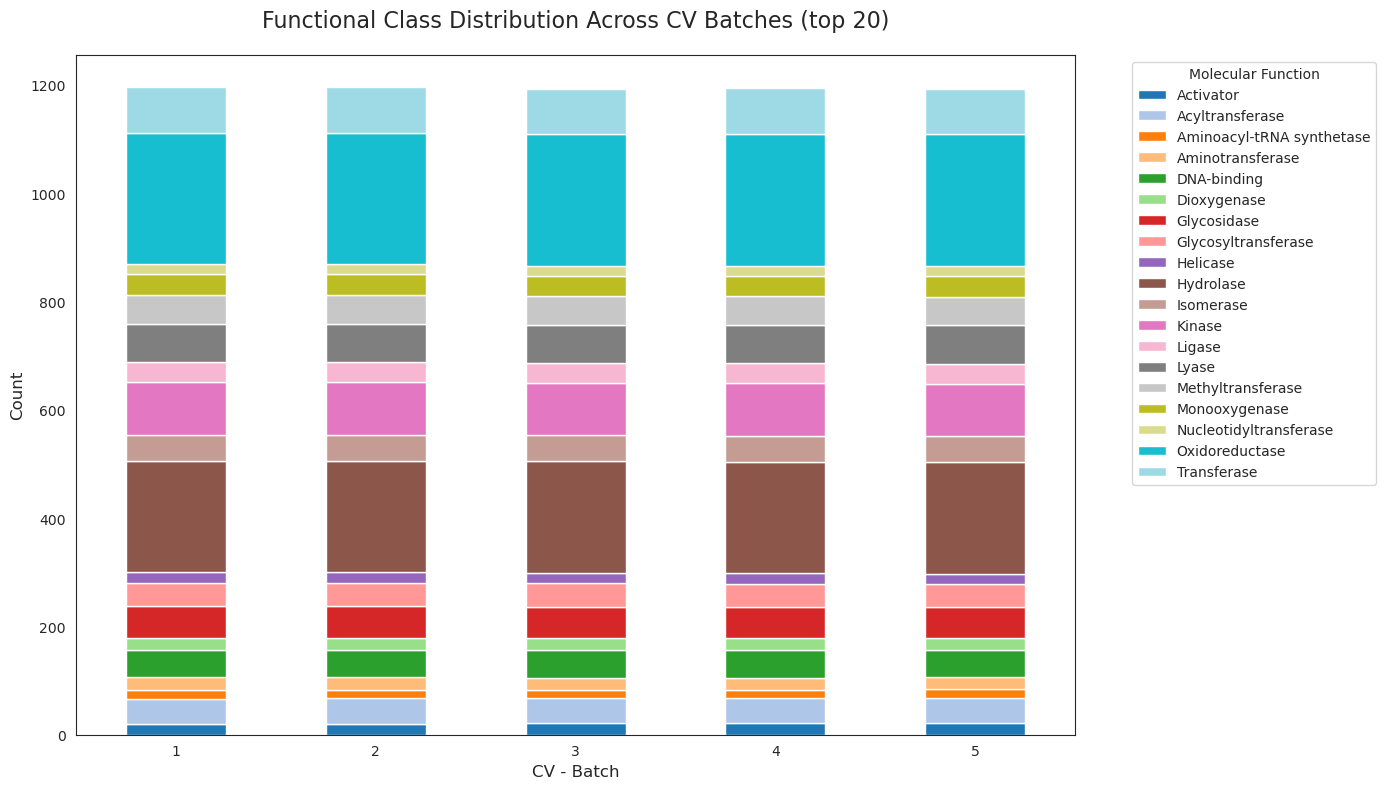

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/pdb_splits.csv')

# Get training set 
train_df = df[df['Split'] == 'training'].copy()
train_df['CV_Batch'] = train_df['CV_Batch'].astype(int)

# Get top 20 classes
cls_df = pd.read_csv('data/pdb_uniprot_class.csv')
top_20 = cls_df['Protein_Class_Uniprot'].value_counts().head(20).index

# Filter training data
plot_df = train_df.merge(cls_df[['PDB_ID', 'Protein_Class_Uniprot']], on='PDB_ID')
plot_df = plot_df[plot_df['Protein_Class_Uniprot'].isin(top_20)]

# Group
batch_dist = plot_df.groupby(['CV_Batch', 'Protein_Class_Uniprot']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.set_style("white")
batch_dist.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')

plt.title("Functional Class Distribution Across CV Batches (top 20)", fontsize=16, pad=20)
plt.xlabel("CV - Batch", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Molecular Function", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("data/batch_stratification_check.png", dpi=300)
plt.show()

Due to GitHub upload limitation, "BioLiP_results.txt" and "filtered_pdbs.csv" can be found in https://drive.google.com/drive/folders/1Uykx9VZzXgQsscDlKrLAYuNW-lNTnR0f?usp=sharing